# Single Cell Results Visualization (V3)

This notebook plots results from `cluster-generalizationV3.py`, with **correct normalization** re-computed locally.

**Key features:**
- Loads saved raw scores (e.g., `stable_in`, `stable_out`) from results files
- Loads original data `X_list` from `Real-SingleCell/RNA.pkl`
- Uses saved `train_idx_list` and `test_idx_list` to identify which batches each rotation used
- Re-computes `batch_scale(X)` for each batch (using correct definition: `(1/n) * sum_i ||x_i||^2`)
- Normalizes all worst-case scores by the global `max_scale_global` (correctly computed)
- This fixes the normalization bug in `cluster-generalizationV3.py` where `np.mean(X**2)` was used instead of `batch_scale(X)`

**No need to re-run the expensive simulations!**


In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ------------------------------------------------------------
# NeurIPS-ish global style (your previous setup)
# ------------------------------------------------------------
plt.rcParams.update({
    # --- NeurIPS-style, larger text for print ---
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "figure.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",

    # Scaled up for visibility in print
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 13,
    "legend.fontsize": 15,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

# ------------------------------------------------------------
# Helper function: batch_scale (matching cluster-generalizationV3.py)
# ------------------------------------------------------------
def batch_scale(X):
    """
    Scale used in the normalized metric denominator:
        (1/n) * sum_i ||x_i||^2
    """
    sq_norm = np.sum(X**2, axis=1)  # (n,)
    return float(np.mean(sq_norm))

# ------------------------------------------------------------
# Method labels and colors (consistent with your scheme)
# ------------------------------------------------------------
methods = ["stable", "pooled", "squared", "fair"]
method_labels = {
    "stable":  "StablePCA",
    "pooled":  "PooledPCA",
    "squared": "SquaredPCA",
    "fair":    "FairPCA",
}
method_colors = {
    "pooled":  "#777777",  # charcoal
    "stable":  "#D54E00",  # orange
    "squared": "#1F78B4",  # blue
    "fair":    "#A65628",  # brownish
}

# ------------------------------------------------------------
# Load original data
# ------------------------------------------------------------
for candidate in ["RNA.pkl", "application/RNA.pkl", "../Real-SingleCell/RNA.pkl"]:
    data_path = Path(candidate)
    if data_path.exists():
        break
else:
    raise FileNotFoundError("RNA.pkl not found. Prepare from h5ad and place in application/")

print(f"Loading original data from {data_path}...")
with open(data_path, "rb") as f:
    X_list = pickle.load(f)
print(f"Loaded {len(X_list)} batches")

# ------------------------------------------------------------
# Aggregate results across jobs (fixed n_components = 50)
# Re-compute normalization using correct batch_scale
# ------------------------------------------------------------
# cluster-generalization.py saves to results/ when run from project root
for _d in ["results", "application/results", "../saved_results/real_applicationV3"]:
    if os.path.isdir(_d) and any(f.startswith("rotation_test_results_job") for f in os.listdir(_d)):
        results_dir = _d
        break
else:
    results_dir = "results"  # default; run cluster-generalization.py first
num_jobs = 20
n_components_fixed = 150  # This notebook is designed for k = 50 only

# Store raw scores and indices for each rotation
# Format: list of dicts, each with {method: score, train_idx: [...], test_idx: [...]}
all_rotations = []

for job in range(num_jobs):
    fpath = os.path.join(results_dir, f"rotation_test_results_job{job}.pkl")
    if not os.path.exists(fpath):
        print(f"⚠️ Missing file: {fpath}")
        continue
    with open(fpath, "rb") as f:
        res_job = pickle.load(f)

    # Handle two possible formats:
    # 1) Old format: res is a flat dict with keys like 'stable_in', 'stable_out', ...
    # 2) New format: res is a dict with nested dicts keyed by 'n_components_50', 'n_components_100', ...
    if isinstance(res_job, dict) and any(k.startswith("n_components_") for k in res_job.keys()):
        key_50 = f"n_components_{n_components_fixed}"
        if key_50 not in res_job:
            print(f"⚠️ Key {key_50} not found in {fpath}, available keys: {list(res_job.keys())}")
            continue
        res = res_job[key_50]
    else:
        res = res_job

    # Extract train_idx_list and test_idx_list
    train_idx_list = res.get("train_idx_list", [])
    test_idx_list = res.get("test_idx_list", [])
    
    if len(train_idx_list) != len(test_idx_list):
        print(f"⚠️ Mismatch in train/test idx lists for job {job}")
        continue
    
    num_rotations = len(train_idx_list)
    
    # For each rotation, store raw scores and indices
    for rot_idx in range(num_rotations):
        rotation_data = {
            "train_idx": train_idx_list[rot_idx],
            "test_idx": test_idx_list[rot_idx],
        }
        for m in methods:
            in_key = f"{m}_in"
            out_key = f"{m}_out"
            if in_key in res and rot_idx < len(res[in_key]):
                rotation_data[f"{m}_in"] = res[in_key][rot_idx]
            if out_key in res and rot_idx < len(res[out_key]):
                rotation_data[f"{m}_out"] = res[out_key][rot_idx]
        all_rotations.append(rotation_data)

print(f"Loaded {len(all_rotations)} rotations across {num_jobs} jobs")

# ------------------------------------------------------------
# Re-compute normalized scores using correct batch_scale
# Normalize by global max_scale_global
# ------------------------------------------------------------
print("\nRe-computing normalized scores using correct batch_scale...")

# Track global max_scale_global (across all batches in all rotations)
max_scale_global_all = -np.inf

# For each rotation, compute normalized worst-case scores
in_normalized = {m: [] for m in methods}
out_normalized = {m: [] for m in methods}

for rot in all_rotations:
    train_idx = rot["train_idx"]
    test_idx = rot["test_idx"]
    
    # Compute batch_scale for all batches in this rotation
    train_scales = [batch_scale(X_list[i]) for i in train_idx]
    test_scales = [batch_scale(X_list[i]) for i in test_idx]
    
    # Update global max_scale
    max_scale_global_all = max(
        max_scale_global_all,
        max(train_scales + test_scales) if (train_scales + test_scales) else -np.inf
    )
    
    # For each method, normalize the worst-case score by global max_scale_global_all
    for m in methods:
        if f"{m}_in" in rot:
            in_normalized[m].append(rot[f"{m}_in"] / max_scale_global_all)
        if f"{m}_out" in rot:
            out_normalized[m].append(rot[f"{m}_out"] / max_scale_global_all)

print(f"Global max_scale_global: {max_scale_global_all:.6e}")
print(f"Normalized {sum(len(in_normalized[m]) for m in methods)} in-dist scores")
print(f"Normalized {sum(len(out_normalized[m]) for m in methods)} out-dist scores")

# Convert to ordered lists for plotting
in_data = [np.array(in_normalized[m]) for m in methods]
out_data = [np.array(out_normalized[m]) for m in methods]
box_labels = [method_labels[m] for m in methods]
box_colors = [method_colors[m] for m in methods]


Loading original data from RNA.pkl...
Loaded 12 batches
Loaded 200 rotations across 20 jobs

Re-computing normalized scores using correct batch_scale...
Global max_scale_global: 1.368043e+03
Normalized 800 in-dist scores
Normalized 800 out-dist scores


In [5]:
# Worst-case (smallest) for each method: in-dist and out-dist
print("=" * 60)
print("Worst-case (min) normalized explained variance per method")
print("=" * 60)
print(f"{'Method':<14} {'In-dist (worst)':>16} {'Out-dist (worst)':>16}")
print("-" * 60)
worst_in = {m: np.min(in_normalized[m]) for m in methods}
worst_out = {m: np.min(out_normalized[m]) for m in methods}
for m in methods:
    print(f"{method_labels[m]:<14} {worst_in[m]:>16.4f} {worst_out[m]:>16.4f}")
print("=" * 60)

# Improved percentage of StablePCA vs other methods (positive = StablePCA better)
print("\nStablePCA improvement vs other methods (worst-case):")
print("  (StablePCA - Other) / Other * 100%")
print("-" * 50)
others = [m for m in methods if m != "stable"]
for m in others:
    imp_in = (worst_in["stable"] - worst_in[m]) / worst_in[m] * 100 if worst_in[m] != 0 else 0
    imp_out = (worst_out["stable"] - worst_out[m]) / worst_out[m] * 100 if worst_out[m] != 0 else 0
    print(f"  vs {method_labels[m]:<12}: in-dist {imp_in:>+6.1f}%   out-dist {imp_out:>+6.1f}%")
print("-" * 50)

Worst-case (min) normalized explained variance per method
Method          In-dist (worst) Out-dist (worst)
------------------------------------------------------------
StablePCA                0.4996           0.4872
PooledPCA                0.4615           0.4582
SquaredPCA               0.4823           0.4610
FairPCA                  0.4723           0.4609

StablePCA improvement vs other methods (worst-case):
  (StablePCA - Other) / Other * 100%
--------------------------------------------------
  vs PooledPCA   : in-dist   +8.3%   out-dist   +6.3%
  vs SquaredPCA  : in-dist   +3.6%   out-dist   +5.7%
  vs FairPCA     : in-dist   +5.8%   out-dist   +5.7%
--------------------------------------------------


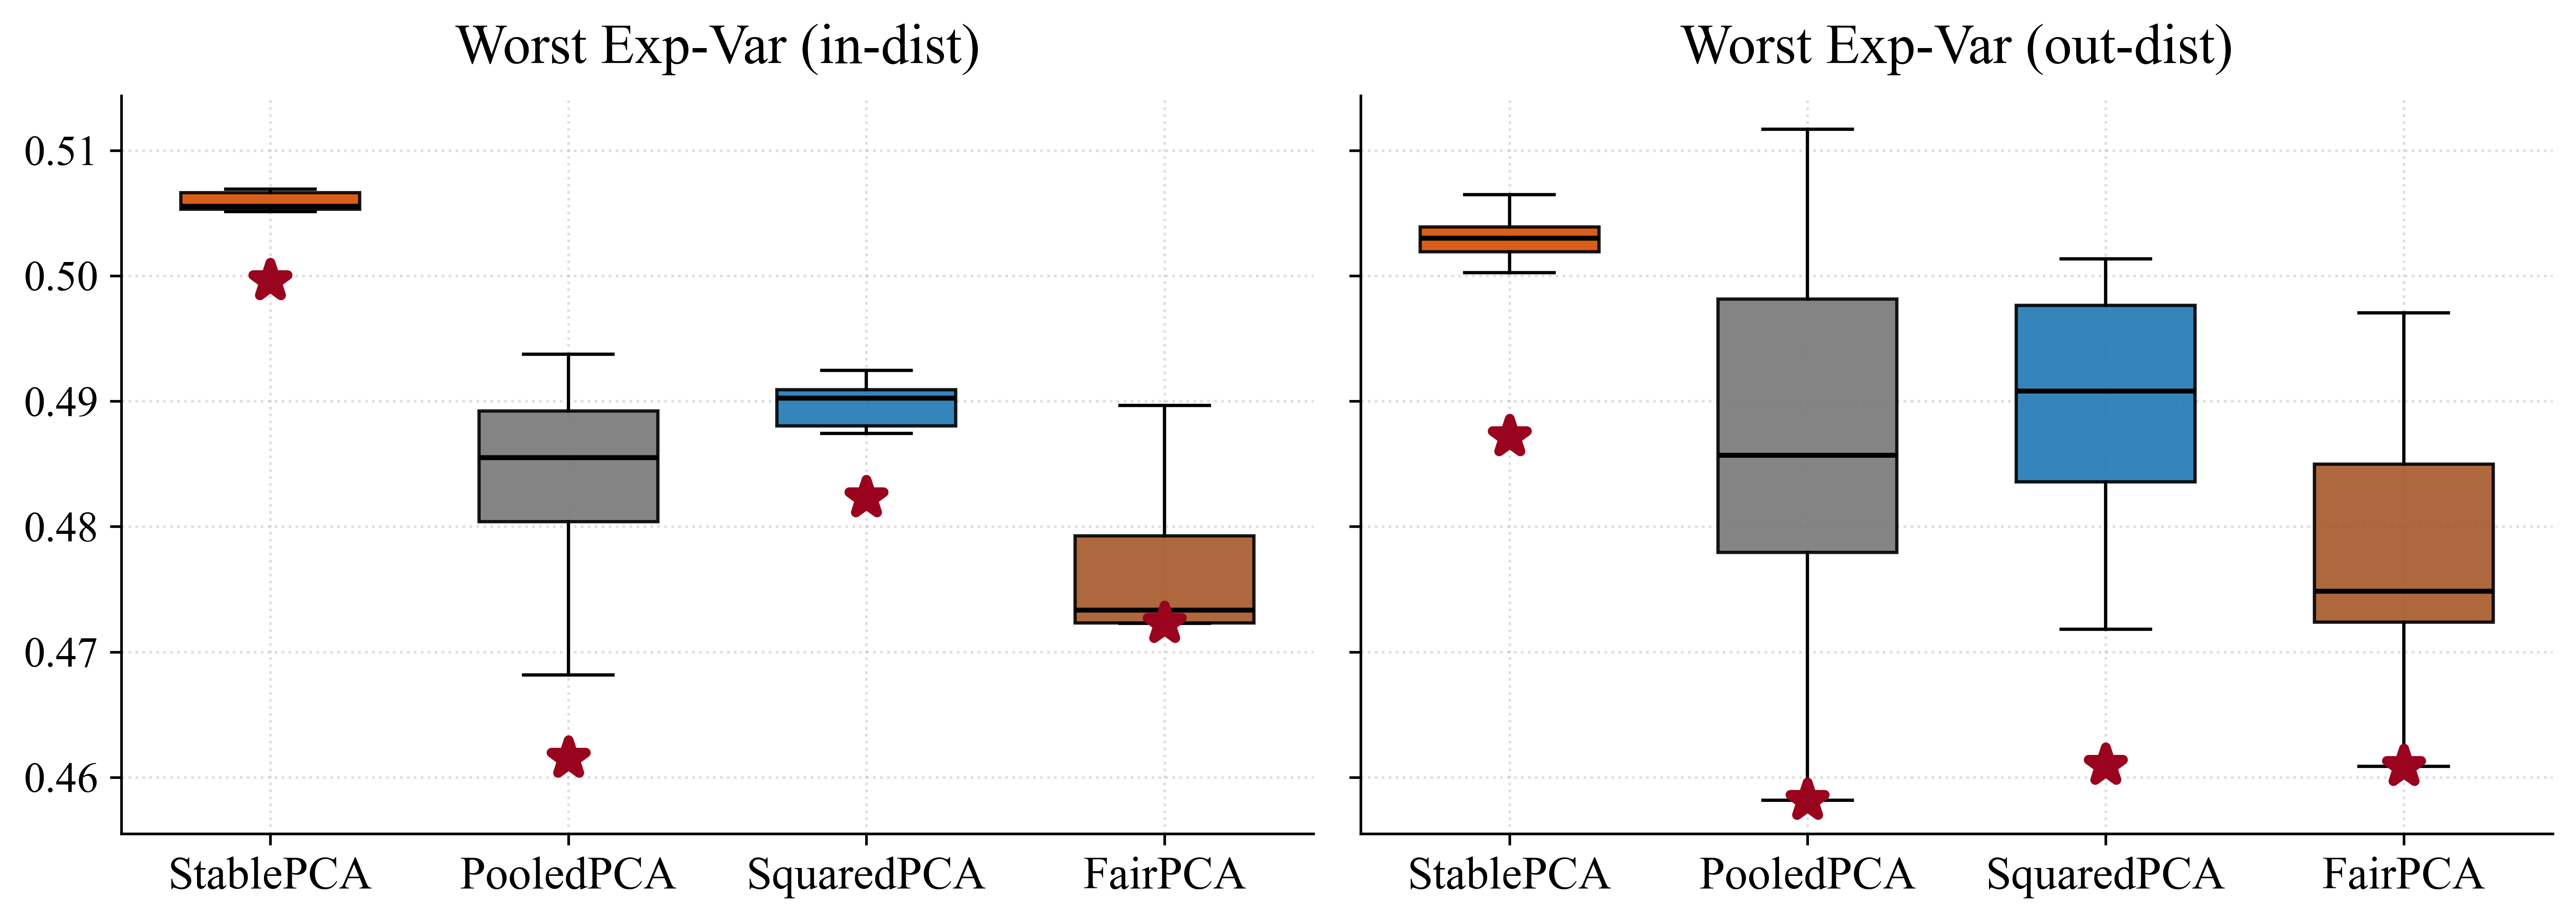


All data has been normalized by max_scale_global = 1.368043e+03
Note: Normalization was re-computed using correct batch_scale() function,
      matching the definition in cluster-generalizationV3.py


In [6]:
# ------------------------------------------------------------
# Plot: two subfigures, in-dist & out-dist
# ------------------------------------------------------------
fig, (ax_in, ax_out) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
plt.subplots_adjust(wspace=0.25, bottom=0.18)

# Helper to style a boxplot axis
def style_boxplot(ax, title, ylabel=None):
    ax.set_title(title, pad=10)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# --- Left: In-distribution worst-case explained variance (normalized) ---
bp_in = ax_in.boxplot(
    in_data,
    tick_labels=box_labels,
    showfliers=False,        # remove outliers for better visualization
    patch_artist=True,
    widths=0.6,
)

for patch, c in zip(bp_in["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)
for median in bp_in["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

# Add x marks at worst-case (min) for each method
x_positions = range(1, len(in_data) + 1)
worst_in_vals = [np.min(d) for d in in_data]
ax_in.scatter(x_positions, worst_in_vals, marker="*", s=120, c='#9A031E', linewidths=3, zorder=5, label=None)

style_boxplot(
    ax_in,
    title=r"Worst Exp-Var (in-dist)",
    ylabel=None,
)
# ax_in.legend(loc="lower right", fontsize=11)

# --- Right: Out-of-distribution worst-case explained variance (normalized) ---
bp_out = ax_out.boxplot(
    out_data,
    tick_labels=box_labels,
    showfliers=False,
    patch_artist=True,
    widths=0.6,
)

for patch, c in zip(bp_out["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)
for median in bp_out["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

# Add x marks at worst-case (min) for each method
worst_out_vals = [np.min(d) for d in out_data]
ax_out.scatter(x_positions, worst_out_vals, marker="*", s=120, c='#9A031E', linewidths=3, zorder=5, label=None)

style_boxplot(
    ax_out,
    title=r"Worst Exp-Var (out-dist)",
    ylabel=None,
)

plt.tight_layout()
# Optional: save
plt.savefig("single_cell_V3-k150.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"\nAll data has been normalized by max_scale_global = {max_scale_global_all:.6e}")
print("Note: Normalization was re-computed using correct batch_scale() function,")
print("      matching the definition in cluster-generalizationV3.py")
